# 07 · Targeted analyses: record index, RMC correlation, threshold spread

Three small, self-contained analyses anchored to the final campaign's recorded artifacts.  
The only model fits are one record-index retrain and twenty bootstrap refits; everything else is computed from recorded artifacts or the raw table.  
Needs the dataset via `XOPA_DATA`.

### Setup

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

from _shared import (
    CHRONOLOGICAL_INTERVAL,
    ONE_HALF_COL,
    SINGLE_COL,
    feature_category,
    init_notebook,
    jload,
    run_dir,
)

FIG_DIR, savefig = init_notebook("07_targeted_analyses")

assert "XOPA_DATA" in os.environ, "set XOPA_DATA to the dataset CSV path"
DATA_PATH = Path(os.environ["XOPA_DATA"])
assert DATA_PATH.exists(), f"dataset not found: {DATA_PATH}"

campaign: dce-full-rffs-4backbones-xgb-analyses-v2-2026-08-11
figures -> /Users/berthier/Development/PhD/xopa/results/notebook-figures/07_targeted_analyses


/Users/berthier/Development/PhD/xopa/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Shared reconstruction: the recorded split, scaler, and final features

In [2]:
rffs_dir = run_dir("xgboost", "rffs")
summary = jload(rffs_dir / "rffs_summary.json")
manifest = jload(rffs_dir / "manifest.json")
final_features = summary["final_features"]

raw = pd.read_csv(DATA_PATH)
raw = raw.drop(columns=[c for c in raw.columns if c.startswith("Unnamed")])
y_all = raw["data_164"].astype(float)

prep = np.load(rffs_dir / "preprocessing.npz", allow_pickle=True)
scale_map = pd.DataFrame(
    {"mean": prep["mean"], "scale": prep["scale"]},
    index=[str(f) for f in prep["feature_names"]],
).loc[final_features]
x_std = (raw[final_features] - scale_map["mean"].to_numpy()) / scale_map[
    "scale"
].to_numpy()

assignments = pd.read_csv(rffs_dir / "split_assignments.csv").set_index("row_id")
splits = {
    name: assignments.index[assignments["split"] == name]
    for name in ("train", "validation", "calibration", "test")
}
xgb_cfg = manifest["config"]["models"]["xgboost"]
seed = manifest["config"]["split"]["seed"]
early_stop = manifest["config"]["models"]["early_stopping_rounds"]
print({name: len(ids) for name, ids in splits.items()})
print(f"final features ({len(final_features)}): {final_features}")

{'train': 24588, 'validation': 2634, 'calibration': 2634, 'test': 5269}
final features (20): ['data_474', 'data_118', 'data_385', 'data_475', 'data_085', 'data_137', 'data_064', 'data_108', 'data_054', 'data_002', 'data_001', 'data_113', 'data_129', 'data_106', 'data_136', 'data_070', 'data_151', 'data_103', 'data_139', 'data_104']


## The chronological record index as a training feature

One retrain adds the chronological record index as a predictor.  
Its SHAP profile tests whether the fitted response varies systematically over the production sequence. Exact timestamps and elapsed intervals are unavailable.  
The baseline is refit on this machine so the comparison is within-machine.  
The shaded region reuses the four-group post-hoc window selected from the original SHAP profile, it is not treated as an independently detected regime.

In [3]:
def fit_xgb(features: pd.DataFrame) -> XGBRegressor:
    model = XGBRegressor(
        **xgb_cfg, random_state=seed, early_stopping_rounds=early_stop
    )
    model.fit(
        features.loc[splits["train"]],
        y_all.loc[splits["train"]],
        eval_set=[(features.loc[splits["validation"]], y_all.loc[splits["validation"]])],
        verbose=False,
    )
    return model


x_time = x_std.copy()
x_time["record_index"] = x_time.index.to_numpy(dtype=float)

base_model = fit_xgb(x_std)
time_model = fit_xgb(x_time)
r2_base = r2_score(y_all.loc[splits["test"]], base_model.predict(x_std.loc[splits["test"]]))
r2_time = r2_score(
    y_all.loc[splits["test"]], time_model.predict(x_time.loc[splits["test"]])
)
print(f"test R2 baseline (20 features, this machine): {r2_base:.3f}")
print(f"test R2 with record_index (21 features):      {r2_time:.3f}")
print(f"delta: {r2_time - r2_base:+.3f}")

test R2 baseline (20 features, this machine): 0.779
test R2 with record_index (21 features):      0.774
delta: -0.005


In [4]:
explanation = shap.TreeExplainer(time_model)(x_time, check_additivity=False)
shap_time = pd.DataFrame(
    np.asarray(explanation.values), index=x_time.index, columns=x_time.columns
)
importance_time = shap_time.abs().mean().sort_values(ascending=False)
rank = int(np.where(importance_time.index == "record_index")[0][0]) + 1
print(
    f"record_index importance: mean |SHAP| = "
    f"{importance_time['record_index']:.4f}, rank {rank} of {len(importance_time)}"
)
print(importance_time.round(4).to_string())

record_index importance: mean |SHAP| = 0.1078, rank 3 of 21
data_474        0.3540
data_118        0.1448
record_index    0.1078
data_475        0.0690
data_064        0.0688
data_385        0.0613
data_137        0.0547
data_054        0.0542
data_085        0.0521
data_151        0.0511
data_001        0.0502
data_113        0.0473
data_002        0.0450
data_136        0.0441
data_108        0.0432
data_106        0.0392
data_070        0.0384
data_104        0.0375
data_129        0.0357
data_139        0.0278
data_103        0.0240


mean SHAP(record_index): inside window -0.1470, outside +0.0151
saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/07_targeted_analyses/p14_time_coordinate_profile.pdf/.png


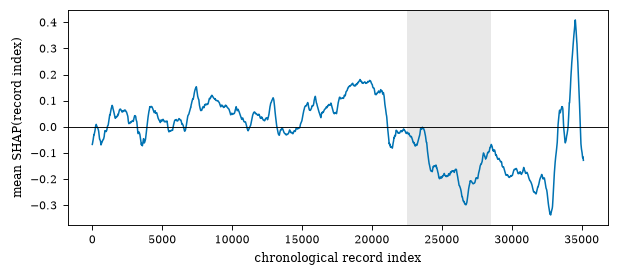

In [5]:
ROLLING_WINDOW = 400
MIN_ROLLING_RECORDS = 100
profile = shap_time["record_index"]
rolling = profile.rolling(ROLLING_WINDOW, center=True, min_periods=MIN_ROLLING_RECORDS).mean()
inside = profile.loc[
    (profile.index >= CHRONOLOGICAL_INTERVAL[0])
    & (profile.index <= CHRONOLOGICAL_INTERVAL[1])
]
outside = profile.loc[
    (profile.index < CHRONOLOGICAL_INTERVAL[0])
    | (profile.index > CHRONOLOGICAL_INTERVAL[1])
]
print(
    f"mean SHAP(record_index): inside window {inside.mean():+.4f}, "
    f"outside {outside.mean():+.4f}"
)

fig, ax = plt.subplots(figsize=(ONE_HALF_COL, 2.4))
ax.plot(profile.index, rolling, color="#0072B2", lw=1.0)
ax.axhline(0, color="black", lw=0.6)
ax.axvspan(*CHRONOLOGICAL_INTERVAL, color="gray", alpha=0.18, lw=0)
ax.set_xlabel("chronological record index")
ax.set_ylabel("mean SHAP(record index)")
savefig(fig, "p14_time_coordinate_profile")
plt.show()

## Correlation within the retained RMC features

The credit-dilution check: if the retained RMC features are strongly inter-correlated, SHAP splits credit among them, depressing individual ranks while inflating the count.  
Computed from the recorded SHAP bundle's feature values.

retained RMC features (9): ['data_118', 'data_137', 'data_108', 'data_113', 'data_129', 'data_106', 'data_136', 'data_139', 'data_104']
|r| off-diagonal: max 0.299, mean 0.120, pairs with |r| > 0.8: 0, > 0.5: 0
saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/07_targeted_analyses/p21_rmc_correlation.pdf/.png


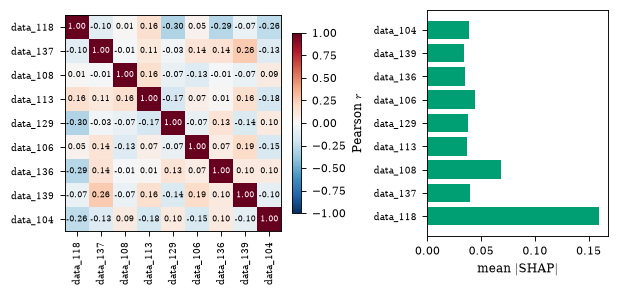

In [6]:
exp_dir = run_dir("xgboost", "explain")
bundle = np.load(exp_dir / "shap_bundle.npz", allow_pickle=True)
names = [str(f) for f in bundle["feature_names"]]
values = pd.DataFrame(bundle["feature_values"], columns=names)
importance_rec = (
    pd.DataFrame(bundle["shap_values"], columns=names).abs().mean()
)
rmc = [f for f in names if feature_category(f) == "RMC"]
corr = values[rmc].corr()
off = corr.where(~np.eye(len(rmc), dtype=bool))
print(f"retained RMC features ({len(rmc)}): {rmc}")
print(
    f"|r| off-diagonal: max {off.abs().max().max():.3f}, "
    f"mean {off.abs().stack().mean():.3f}, "
    f"pairs with |r| > 0.8: {int((off.abs() > 0.8).sum().sum() / 2)}, "
    f"> 0.5: {int((off.abs() > 0.5).sum().sum() / 2)}"
)

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(ONE_HALF_COL, 2.6), width_ratios=[1.2, 1]
)
im = ax1.imshow(corr.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
ax1.set_xticks(range(len(rmc)), rmc, rotation=90, fontsize=6)
ax1.set_yticks(range(len(rmc)), rmc, fontsize=6)
for i in range(len(rmc)):
    for j in range(len(rmc)):
        ax1.text(
            j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=5,
            color="white" if abs(corr.iloc[i, j]) > 0.6 else "black",
        )
fig.colorbar(im, ax=ax1, shrink=0.8, label="Pearson $r$")
ax2.barh(range(len(rmc)), importance_rec[rmc].to_numpy(), color="#009E73")
ax2.set_yticks(range(len(rmc)), rmc, fontsize=6)
ax2.set_xlabel("mean $|$SHAP$|$")
savefig(fig, "p21_rmc_correlation")
plt.show()

## Split-location spread over twenty bootstrap refits

For each bootstrap resample of the training split, the model is refit with the recorded protocol and every split threshold involving the three leading features is extracted.  
For each feature and refit, the diagnostic reports the split with the highest gain.

refit 1/20 done
refit 2/20 done
refit 3/20 done
refit 4/20 done
refit 5/20 done
refit 6/20 done
refit 7/20 done
refit 8/20 done
refit 9/20 done
refit 10/20 done
refit 11/20 done
refit 12/20 done
refit 13/20 done
refit 14/20 done
refit 15/20 done
refit 16/20 done
refit 17/20 done
refit 18/20 done
refit 19/20 done
refit 20/20 done
          n_refits  top-gain split mean  std    min    max
feature                                                   
data_474        20                0.658  0.0  0.658  0.658
data_118        20               -0.486  0.0 -0.486 -0.486
data_385        20                0.518  0.0  0.518  0.518
saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/07_targeted_analyses/p23_split_location_spread.pdf/.png


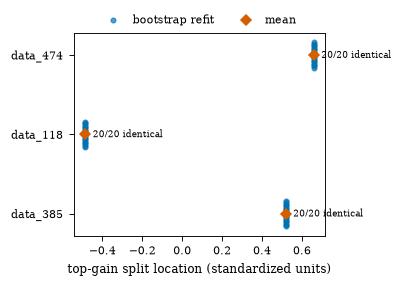

In [7]:
TOP_FEATURES = list(importance_rec.sort_values(ascending=False).index[:3])
N_BOOT = 20
rng = np.random.default_rng(seed)
train_ids = splits["train"].to_numpy()
locations = {f: [] for f in TOP_FEATURES}
for b in range(N_BOOT):
    resample = rng.choice(train_ids, size=len(train_ids), replace=True)
    model = XGBRegressor(
        **xgb_cfg, random_state=seed + b, early_stopping_rounds=early_stop
    )
    model.fit(
        x_std.loc[resample],
        y_all.loc[resample],
        eval_set=[(x_std.loc[splits["validation"]], y_all.loc[splits["validation"]])],
        verbose=False,
    )
    trees = model.get_booster().trees_to_dataframe()
    for f in TOP_FEATURES:
        block = trees[trees["Feature"] == f]
        if block.empty:
            continue
        best = block.loc[block["Gain"].idxmax(), "Split"]
        locations[f].append(float(best))
    print(f"refit {b + 1}/{N_BOOT} done", flush=True)

rows = []
for f in TOP_FEATURES:
    loc = np.asarray(locations[f])
    rows.append(
        {
            "feature": f,
            "n_refits": len(loc),
            "top-gain split mean": round(loc.mean(), 3),
            "std": round(loc.std(), 3),
            "min": round(loc.min(), 3),
            "max": round(loc.max(), 3),
        }
    )
spread = pd.DataFrame(rows).set_index("feature")
print(spread.to_string())

fig, ax = plt.subplots(figsize=(SINGLE_COL, 2.5))
display_offsets = np.linspace(-0.16, 0.16, N_BOOT)
for i, f in enumerate(TOP_FEATURES):
    loc = np.asarray(locations[f])
    ax.plot(
        loc, i + display_offsets[: len(loc)], "o", ms=3, alpha=0.65,
        color="#0072B2", label="bootstrap refit" if i == 0 else None,
    )
    ax.plot(
        loc.mean(), i, "D", ms=5, color="#D55E00", zorder=3,
        label="mean" if i == 0 else None,
    )
    unique_count = np.unique(np.round(loc, decimals=6)).size
    if unique_count == 1:
        label = f"{len(loc)}/{N_BOOT} identical"
    else:
        label = f"{unique_count} distinct locations"
    ax.annotate(
        label, (loc.mean(), i), xytext=(5, 0), textcoords="offset points",
        va="center", fontsize=6,
    )
ax.set_yticks(range(len(TOP_FEATURES)), TOP_FEATURES)
ax.invert_yaxis()
ax.set_xlabel("top-gain split location (standardized units)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.14), ncol=2)
savefig(fig, "p23_split_location_spread")
plt.show()